## AuxTel M1 Pressure Queries - 26-Mar-21

In this notebook, investigate M1 pressure noise issues\
Craig Lage 26-Mar-21

In [1]:
import sys, time, os, asyncio

from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.time import Time, TimeDelta
from lsst_efd_client import EfdClient


In [2]:
# Get EFD client
client = EfdClient('summit_efd')

In [22]:
# These are for finding a rough bracket of the data
#dayObs = '2021-03-23'
#start = Time('2021-03-24T00:00:00') #this is UTC
#end = Time('2021-03-24T02:00:00')
dayObs = '2021-04-07'
start = Time('2021-04-07T16:30:00') #this is UTC
end = Time('2021-04-07T16:40:00')

In [23]:
timestamp = f"time >= '{start}+00:00' AND time <= '{end}+00:00'"
query = f'SELECT "pressure" FROM "efd"."autogen"."lsst.sal.ATPneumatics.m1AirPressure" WHERE {timestamp}'
pressure = await client.influx_client.query(query)

query = f'SELECT "pressure" FROM "efd"."autogen"."lsst.sal.ATPneumatics.command_m1SetPressure" WHERE {timestamp}'
set_pressure = await client.influx_client.query(query)
print(start, end)
print(len(pressure), len(set_pressure))

2021-04-07T16:30:00.000 2021-04-07T16:40:00.000
600 101


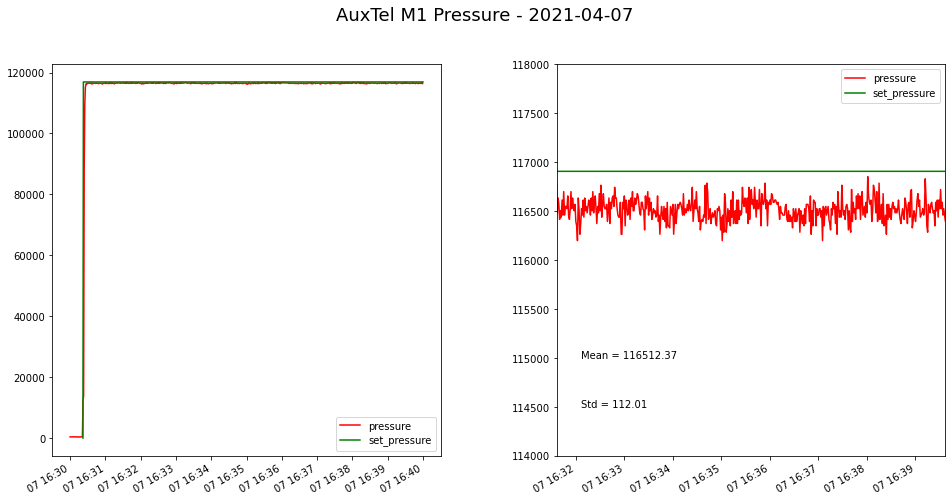

In [24]:
# Plot it
fig = plt.figure(figsize = (16,8))
plt.suptitle(f"AuxTel M1 Pressure - {dayObs}", fontsize = 18)
plt.subplots_adjust(wspace=0.3)
plt.subplot(1,2,1)
ax1 = pressure['pressure'].plot(legend=True, color='red')
ax1 = set_pressure['pressure'].plot(legend=True, color='green', label='set_pressure')

plt.subplot(1,2,2)
ax2 = pressure['pressure'].plot(legend=True, color='red')
ax2 = set_pressure['pressure'].plot(legend=True, color='green', label='set_pressure')
startPlot = Time('2021-04-07T16:31:00') #this is UTC
endPlot = Time('2021-04-07T16:39:00')
textPlot = startPlot + TimeDelta(30, format='sec')
ax2.set_xlim(startPlot.tai.isot,endPlot.tai.isot)
ax2.set_ylim(114000, 118000)

p = pressure[startPlot.tai.isot:endPlot.tai.isot]
pMean = p.mean()
pStd = p.std()

ax2.text(textPlot.tai.isot, 115000, f"Mean = {pMean[0]:.2f}")
ax2.text(textPlot.tai.isot, 114500, f"Std = {pStd[0]:.2f}")
plt.savefig(f"/home/craiglagegit/DATA/M1_Pressure_{dayObs}.pdf")

In [ ]:
plt.subplot(1,2,2)
ax2 = pressure['pressure'].plot(legend=True, color='red')
ax2 = set_pressure['pressure'].plot(legend=True, color='green', label='set_pressure')
startPlot = Time('2021-02-18T23:30:00') #this is UTC
endPlot = Time('2021-02-18T23:40:00')
textPlot = startPlot + TimeDelta(30, format='sec')
ax2.set_xlim(startPlot.tai.isot,endPlot.tai.isot)
ax2.set_ylim(114000, 118000)

p = pressure[startPlot.tai.isot:endPlot.tai.isot]
pMean = p.mean()
pStd = p.std()

ax2.text(textPlot.tai.isot, 115000, f"Mean = {pMean[0]:.2f}")
ax2.text(textPlot.tai.isot, 114500, f"Std = {pStd[0]:.2f}")
#plt.savefig(f"/home/craiglagegit/DATA/M1_Pressure_{dayObs}.pdf")